## CSV 1: Clean, Ideal Sales Dataset (Baseline)

**Description**  
A well-maintained CRM and sales transactions export featuring clean column names, complete data, consistent datatypes, and realistic sales lifecycle fields with multiple sales metrics beyond revenue.

**Purpose**
- Serve as a control dataset
- Validate platform behavior under ideal conditions
- Act as a benchmark for comparison with later degraded datasets


Dataset Generation

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)

N_ROWS = 3000

start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)

def random_date(start, end):
    return start + timedelta(days=random.randint(0, (end - start).days))

products = [
    (101, "CRM Pro", "Software"),
    (102, "Analytics Suite", "Software"),
    (103, "Sales Booster", "Software"),
    (201, "POS Terminal", "Hardware"),
    (202, "Receipt Printer", "Hardware"),
]

regions = ["North America", "Europe", "Asia"]
countries = ["USA", "Germany", "UK", "India", "Pakistan"]
channels = ["Inbound", "Outbound", "Partner"]
stages = ["Lead", "Qualified", "Proposal", "Won", "Lost"]
salespeople = [f"Salesperson_{i}" for i in range(1, 16)]

rows = []

for i in range(N_ROWS):
    order_date = random_date(start_date, end_date)
    lead_date = order_date - timedelta(days=random.randint(5, 30))
    close_date = order_date + timedelta(days=random.randint(1, 20))
    first_purchase_date = lead_date if random.random() < 0.7 else order_date

    product_id, product_name, category = random.choice(products)
    units = random.randint(1, 20)
    price = random.randint(100, 2000)

    revenue = units * price
    aov = revenue / units
    sales_cycle_days = (close_date - lead_date).days

    rows.append({
        "order_id": f"O-{100000+i}",
        "opportunity_id": f"OPP-{200000+i}",
        "customer_id": f"C-{random.randint(1000, 5000)}",
        "order_date": order_date,
        "lead_date": lead_date,
        "close_date": close_date,
        "first_purchase_date": first_purchase_date,
        "revenue": revenue,
        "units": units,
        "product_id": product_id,
        "product_name": product_name,
        "category": category,
        "salesperson": random.choice(salespeople),
        "region": random.choice(regions),
        "country": random.choice(countries),
        "city": "City_" + str(random.randint(1, 20)),
        "stage": "Won",
        "channel": random.choice(channels),
        "is_returning": random.choice([True, False]),
        "aov": aov,
        "sales_cycle_days": sales_cycle_days
    })

df = pd.DataFrame(rows)

df.to_csv("sales_clean_baseline.csv", index=False)
print("CSV generated: sales_clean_baseline.csv")


CSV generated: sales_clean_baseline.csv


Validation Code

In [2]:
import pandas as pd

df = pd.read_csv("sales_clean_baseline.csv", parse_dates=[
    "order_date", "lead_date", "close_date", "first_purchase_date"
])

# 1. No missing values
assert df.isnull().sum().sum() == 0, "❌ Missing values detected"

# 2. Revenue consistency
assert (df["revenue"] == df["units"] * df["aov"]).all(), "❌ Revenue mismatch"

# 3. Positive numeric fields
numeric_cols = ["revenue", "units", "aov", "sales_cycle_days"]
assert (df[numeric_cols] > 0).all().all(), "❌ Non-positive values found"

# 4. Valid sales cycle
assert (df["close_date"] >= df["lead_date"]).all(), "❌ Invalid sales cycle"

# 5. Single stage consistency
assert df["stage"].nunique() == 1 and df["stage"].iloc[0] == "Won", "❌ Stage inconsistency"

print("✅ Dataset validation passed — clean baseline confirmed.")


✅ Dataset validation passed — clean baseline confirmed.


Gold Truth Analysis

Total Revenue: 32587510
Average Order Value: 10862.503333333334


C:\Users\KRONOS\AppData\Local\Temp\ipykernel_50400\2637971612.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["revenue"]


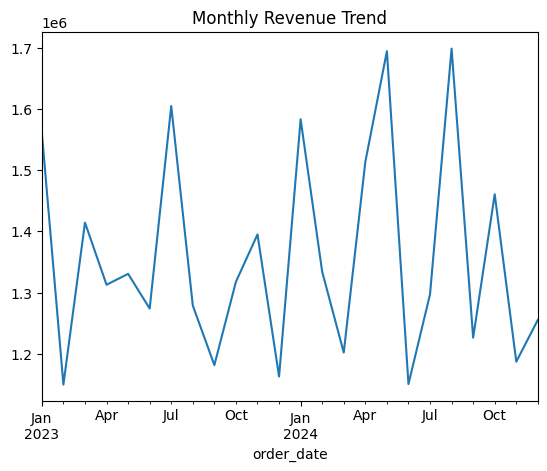

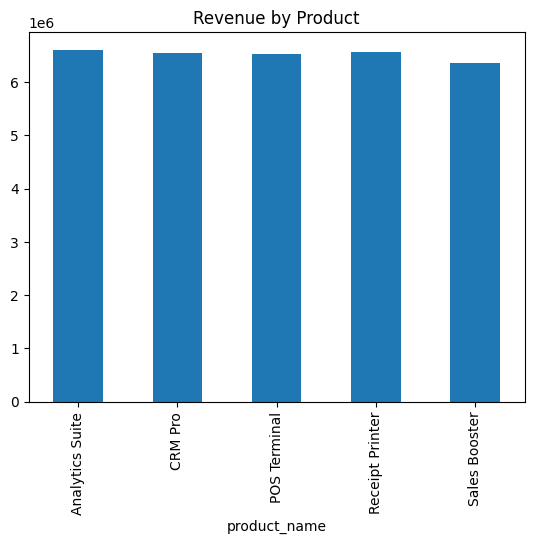

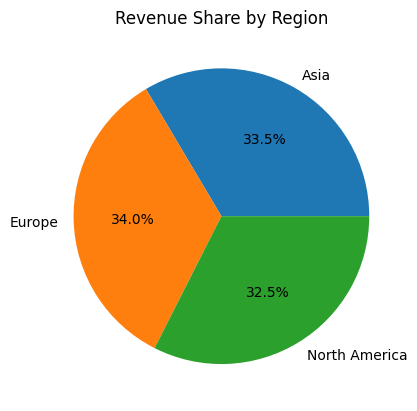

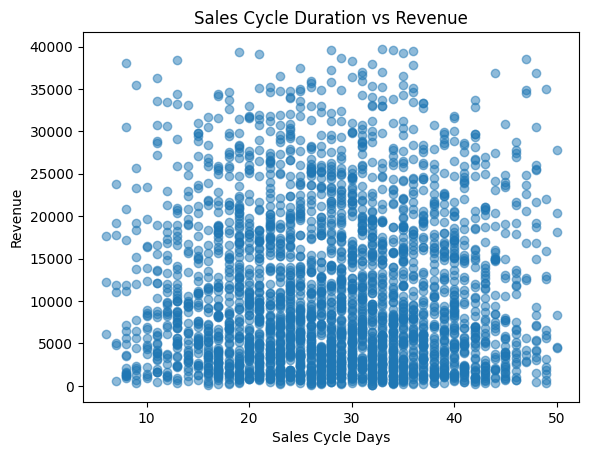

Revenue by Customer Type:
is_returning
False    16146131
True     16441379
Name: revenue, dtype: int64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_clean_baseline.csv", parse_dates=["order_date"])

# ---------------------------
# KPI 1: Total Revenue
# ---------------------------
total_revenue = df["revenue"].sum()
print("Total Revenue:", total_revenue)

# ---------------------------
# KPI 2: Average Order Value
# ---------------------------
avg_aov = df["revenue"].mean()
print("Average Order Value:", avg_aov)

# ---------------------------
# Trend 1: Monthly Revenue Trend
# ---------------------------
monthly_revenue = (
    df.set_index("order_date")
      .resample("M")["revenue"]
      .sum()
)

monthly_revenue.plot(title="Monthly Revenue Trend")
plt.show()

# ---------------------------
# Trend 2: Revenue by Product
# ---------------------------
product_revenue = df.groupby("product_name")["revenue"].sum()
product_revenue.plot(kind="bar", title="Revenue by Product")
plt.show()

# ---------------------------
# Trend 3: Revenue by Region
# ---------------------------
region_revenue = df.groupby("region")["revenue"].sum()
region_revenue.plot(kind="pie", autopct="%1.1f%%", title="Revenue Share by Region")
plt.ylabel("")
plt.show()

# ---------------------------
# Trend 4: Sales Cycle vs Revenue
# ---------------------------
plt.scatter(df["sales_cycle_days"], df["revenue"], alpha=0.5)
plt.title("Sales Cycle Duration vs Revenue")
plt.xlabel("Sales Cycle Days")
plt.ylabel("Revenue")
plt.show()

# ---------------------------
# KPI 3: Returning vs New Customer Revenue
# ---------------------------
returning_split = df.groupby("is_returning")["revenue"].sum()
print("Revenue by Customer Type:")
print(returning_split)
